In [ ]:
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.transforms import v2
from torchsummary import summary
import torch.optim as optim
import torch.nn as nn
from PIL import Image
import numpy as np
import torchvision
import torch
import sys
import os


In [ ]:
drive_path = 'drive/MyDrive/computer_vision/'
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
!pip install einops

In [ ]:
#PLAYGROUND
from skimage.color import rgb2lab, lab2rgb, rgb2gray, gray2rgb
from skimage import data

original = data.astronaut()
grayscale = rgb2gray(original)
color_grayscale = gray2rgb(grayscale)
lab_batch = rgb2lab(original)

# referecne https://fairyonice.github.io/Color-space-defenitions-in-python-RGB-and-LAB.html
print(original.shape)           # RGB
print(grayscale.shape)          # [0..256]
print(color_grayscale.shape)    # [0..256] x3 channels
print(lab_batch.shape)          # L(brigtnes) A(green->red) B(blue->yellow)


(512, 512, 3)
(512, 512)
(512, 512, 3)
(512, 512, 3)


In [ ]:
a=torch.tensor([[[1,2,3,4]]])
a.repeat(2*2,1,1)

tensor([[[1, 2, 3, 4]],

        [[1, 2, 3, 4]],

        [[1, 2, 3, 4]],

        [[1, 2, 3, 4]]])

In [ ]:
import torch.nn as nn
from einops import rearrange
import torchvision
import torch

class ColorizationModel(nn.Module):
    def __init__(self, in_ch=1, device = None):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_ch, 64, kernel_size=(3,3), stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=(3,3), stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=(3,3), stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=(3,3), stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=(3,3), stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=(3,3), stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=(3,3), stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 256, kernel_size=(3,3), stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        self.fusion = nn.Sequential(
            nn.Conv2d(1256, 256, kernel_size=(3,3), stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=(3,3), stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128, 64, kernel_size=(3,3), stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(64, 32, kernel_size=(3,3), stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 16, kernel_size=(3,3), stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 2, kernel_size=(3,3), stride=1, padding=1),
            nn.BatchNorm2d(2),
            nn.Tanh(),
            nn.Upsample(scale_factor=2, mode='nearest'),
        )


    def forward(self, x):
        # print(x.shape)
        x_lum, emb = x
        enc_out = self.encoder(x_lum)

        w, h = enc_out.shape[-2:]

        # fusion
        emb_mat = emb.repeat(1,w*h)
        emb_mat = rearrange(emb_mat, 'b (w h e) -> b e w h', w=w, h=h, e=1000)
        fusion_in = torch.cat((enc_out, emb_mat), dim=1)
        fusion_out = self.fusion(fusion_in)

        out = self.decoder(fusion_out)

        return out

In [ ]:
def load_images(path, norm=True):
    imgs = []
    for filename in os.listdir(path):
        imgs.append(np.array(Image.open(path+filename)))
    imgs = np.array(imgs)
    if norm:
        imgs /= 255.
    return imgs

def img2gray_3ch(img, channel_axis=0):
    # convert imgs to grayscale 1D
    grayscale = rgb2gray(img, channel_axis=channel_axis) # 1 because is batched, 0 if not
    # replicate gray values in all three RGB channels
    grayscale_3d = gray2rgb(grayscale, channel_axis=channel_axis)#

    return grayscale_3d


In [ ]:
from skimage.color import rgb2lab, lab2rgb, rgb2gray, gray2rgb
from torch.utils.data import Dataset
from einops import rearrange
from PIL import Image
import numpy as np
import torch

class ColorizationDataset(Dataset):
    def __init__(self, data, use_transforms=True, device = None):
        self.data = data

        self.prepro_transforms = transforms.Compose([
                transforms.ToTensor(),
                v2.RandomHorizontalFlip(0.5),
                v2.RandomAffine(degrees=1, translate=(0.05, 0.05)),
            ])

        self.inception_transforms = transforms.Compose([
                v2.Resize((299,299)),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])

        self.color_transforms = transforms.Compose([
                v2.Resize((256,256))
            ])

        self.use_transforms = use_transforms

    def __getitem__(self, index):
        x = Image.fromarray(self.data[index].astype(np.uint8))

        if self.use_transforms:
            x = self.prepro_transforms(x)
            x_in = self.inception_transforms(x)
            x_in = x_in.numpy()
            x_col = self.color_transforms(x)
            x_col = x_col.numpy()

        x_gray = torch.tensor(img2gray_3ch(x_in))

        assert len(x_gray.shape) == 3
        x_lab = rgb2lab(x_col, channel_axis=0)

        assert len(x_lab.shape) == 3
        x_luminance = torch.unsqueeze(torch.tensor(x_lab[0,:,:]), dim=0)
        y = x_lab[1:,:,:] /128.

        return [x_luminance, x_gray], torch.tensor(y)


    def __len__(self):
        return len(self.data)


In [ ]:
print(lab_batch[:,:,0].shape+(1,))

(512, 512, 1)


In [ ]:
batch_size = 32
lr = 1e-5
epochs = 150

In [ ]:
os.system('wget https://www.dropbox.com/s/sakfqp6o8pbgasm/data.tgz')
os.system('tar xvzf data.tgz')

car_img = np.load('x_train.npy')
car_img = car_img.astype('float32')


In [ ]:
train_imgs = load_images(drive_path + 'color_train/', norm = False)
test_imgs = load_images(drive_path + 'color_test/', norm = False)

train_set = ColorizationDataset(car_img)
test_set = ColorizationDataset(car_img[:10])

(x_lum, x), y = train_set[0]

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=1)
test_loader = DataLoader(test_set, batch_size=1, shuffle=True, num_workers=1)

In [ ]:
model = ColorizationModel(device = device)
model.to(device)

ColorizationModel(
  (encoder): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Conv2d(256, 512, kernel_size=(3

In [ ]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, min_lr=1e-7, patience=25)

In [ ]:
inception_model = torch.hub.load('pytorch/vision:v0.10.0', 'inception_v3', pretrained=True)
inception_model.eval()
inception_model.to(device)

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [ ]:
import time
min_loss = np.inf
for epoch in range(epochs):

    running_loss = 0.0
    start = time.time()
    for i, data in enumerate(train_loader, 0):

        (x_lum, x_gray), labels = data[0], data[1].to(device)
        # zero the parameter gradients
        optimizer.zero_grad()

        emb = inception_model(x_gray.to(device))

        outputs = model((x_lum.to(device), emb.to(device)))
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    if running_loss < min_loss:
        min_loss = running_loss
        torch.save(model.state_dict(), f'{drive_path}colorization.pt')
    scheduler.step(running_loss)

    end = time.time()
    print(f'epoch: {epoch+1} ({end-start:.2f}) -- loss: {running_loss / len(train_loader):.4f} -- ETA: {(end-start)*(epochs-epoch):.2f}\n')



/usr/local/lib/python3.10/dist-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/usr/local/lib/python3.10/dist-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


epoch: 1 (26.56) -- loss: 0.2671 -- ETA: 3984.49

epoch: 2 (23.14) -- loss: 0.1499 -- ETA: 3447.19

epoch: 3 (30.00) -- loss: 0.1195 -- ETA: 4439.83

epoch: 4 (25.18) -- loss: 0.0935 -- ETA: 3701.28

epoch: 5 (25.31) -- loss: 0.0743 -- ETA: 3694.78

epoch: 6 (24.57) -- loss: 0.0529 -- ETA: 3562.22

epoch: 7 (25.28) -- loss: 0.0397 -- ETA: 3639.95

epoch: 8 (24.96) -- loss: 0.0316 -- ETA: 3569.17

epoch: 9 (27.17) -- loss: 0.0285 -- ETA: 3857.95

epoch: 10 (23.64) -- loss: 0.0247 -- ETA: 3333.45

epoch: 11 (24.54) -- loss: 0.0232 -- ETA: 3435.68

epoch: 12 (25.05) -- loss: 0.0201 -- ETA: 3481.26

epoch: 13 (24.84) -- loss: 0.0190 -- ETA: 3428.30

epoch: 14 (24.17) -- loss: 0.0183 -- ETA: 3310.86

epoch: 15 (24.91) -- loss: 0.0176 -- ETA: 3387.86

epoch: 16 (25.58) -- loss: 0.0162 -- ETA: 3453.88

epoch: 17 (24.27) -- loss: 0.0161 -- ETA: 3251.76

epoch: 18 (25.69) -- loss: 0.0166 -- ETA: 3417.09

epoch: 19 (24.90) -- loss: 0.0159 -- ETA: 3286.62

epoch: 20 (25.07) -- loss: 0.0145 -- ETA

In [ ]:
model.load_state_dict(torch.load(f'{drive_path}colorization.pt', map_location=torch.device('cpu')))
colorized_imgs = []
orig_imgs = []
a_imgs = []
b_imgs = []
a_hat_imgs = []
b_hat_imgs = []
l_imgs = []
with torch.no_grad():
    for data in test_loader:

        (x_lum, x_gray), labels = data[0], data[1].to(device)

        emb = inception_model(x_gray.to(device))

        outputs = model((x_lum.to(device), emb.to(device)))[0,...]

        outputs *= 128
        cur_img = np.zeros((3, 256, 256))
        cur_img[0,:,:] = x_lum[0,...]
        cur_img[1:,:,:] = outputs.cpu()
        orig_imgs.append(torch.cat((x_lum[0,...], labels[0,...]*128), dim=0))
        a_imgs.append(torch.tensor(labels[0,0,:,:]).unsqueeze(0)*128)
        b_imgs.append(torch.tensor(labels[0,1,:,:]).unsqueeze(0)*128)
        a_hat_imgs.append(torch.tensor(outputs[0,:,:]).unsqueeze(0))
        b_hat_imgs.append(torch.tensor(outputs[1,:,:]).unsqueeze(0))
        l_imgs.append(x_lum[0,...])
        colorized_imgs.append(cur_img)

<ipython-input-202-34bfcaf3d0fe>:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  a_imgs.append(torch.tensor(labels[0,0,:,:]).unsqueeze(0)*128)
<ipython-input-202-34bfcaf3d0fe>:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b_imgs.append(torch.tensor(labels[0,1,:,:]).unsqueeze(0)*128)
<ipython-input-202-34bfcaf3d0fe>:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  a_hat_imgs.append(torch.tensor(outputs[0,:,:]).unsqueeze(0))
<ipython-input-202-34bfcaf3d0fe>:26: UserWarning: To copy construct from a tensor, it is recommended to use so

In [ ]:
sel_image = 1

/usr/local/lib/python3.10/dist-packages/skimage/_shared/utils.py:394: UserWarning: Color data out of range: Z < 0 in 676 pixels
  return func(*args, **kwargs)


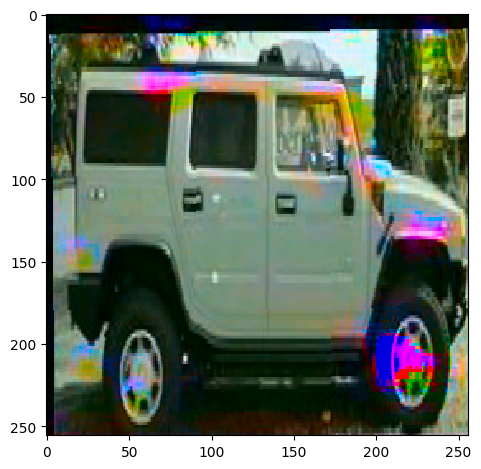

In [ ]:
sel_image = 2
from skimage.io import imshow
from matplotlib.colors import LinearSegmentedColormap
img = torch.tensor(colorized_imgs[sel_image])
img = rearrange(img, 'c h w -> h w c')
img = img.numpy()
img_rgb = lab2rgb(img)
imshow(img_rgb)

<ipython-input-207-5c33313d7162>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(l_imgs[sel_image])


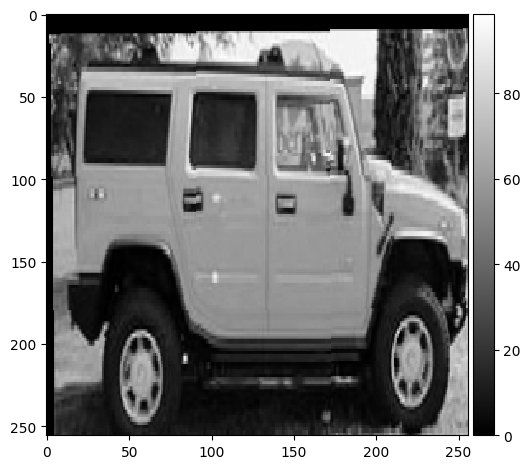

In [ ]:
# plot L layer
from skimage.io import imshow
from matplotlib.colors import LinearSegmentedColormap
img = torch.tensor(l_imgs[sel_image])
img = rearrange(img, 'c h w -> h w c')
img = img.numpy()
imshow(img, cmap='gray')

<ipython-input-208-02c27a58d6f6>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(a_hat_imgs[sel_image])


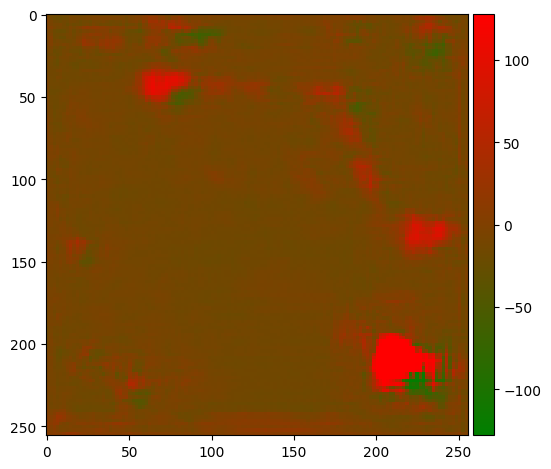

In [ ]:
# plot A layer
from skimage.io import imshow
from matplotlib.colors import LinearSegmentedColormap
img = torch.tensor(a_hat_imgs[sel_image])
img = rearrange(img, 'c h w -> h w c')
img = img.numpy()
cmap = LinearSegmentedColormap.from_list('green_red', ['green', 'red'])
imshow(img , cmap=cmap)

<ipython-input-209-40c017f11c8f>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img = torch.tensor(b_hat_imgs[sel_image])


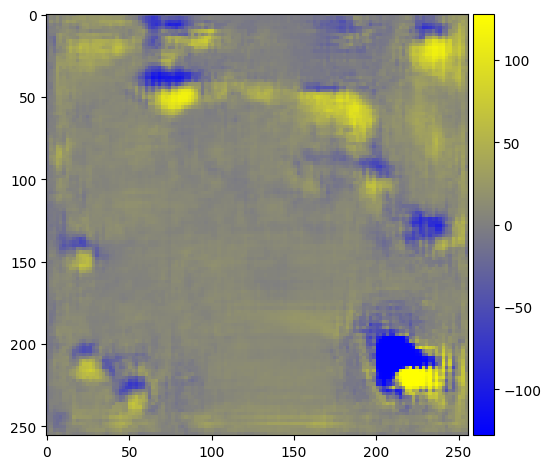

In [ ]:
# plot B layer
from skimage.io import imshow
from matplotlib.colors import LinearSegmentedColormap
img = torch.tensor(b_hat_imgs[sel_image])
img = rearrange(img, 'c h w -> h w c')
img = img.numpy()
cmap = LinearSegmentedColormap.from_list('green_red', ['blue', 'yellow'])
imshow(img , cmap=cmap)